# Spectrogram

This notebook demonstrates how to use YASA to plot a multi-taper spectrogram of a full-night single-channel EEG recording.

Please make sure to install the latest version of YASA first by typing the following line in your terminal or command prompt:

`pip install --upgrade yasa`

In [3]:
import yasa
import numpy as np
import matplotlib.pyplot as plt
import mne
import os, glob
folder = "Y:\\SNL\\FEMS\\PSG"
base = "FEMS_01_S1"

## Load the data and hypnogram

We first load a full-night 3-channels dataset (Cz, Fz, Pz) sampled at 100 Hz. The data is in compressed NumPy format (*.npz*).

In [2]:
files = sorted(glob.glob(os.path.join(folder, base + ".*")))
files


['C:\\Users\\vedag\\OneDrive\\Documents\\Somneuro Lab\\Post-Grad Fall 2025\\YASA_TEST\\FEMS_01_S1.eeg',
 'C:\\Users\\vedag\\OneDrive\\Documents\\Somneuro Lab\\Post-Grad Fall 2025\\YASA_TEST\\FEMS_01_S1.mat',
 'C:\\Users\\vedag\\OneDrive\\Documents\\Somneuro Lab\\Post-Grad Fall 2025\\YASA_TEST\\FEMS_01_S1.vhdr',
 'C:\\Users\\vedag\\OneDrive\\Documents\\Somneuro Lab\\Post-Grad Fall 2025\\YASA_TEST\\FEMS_01_S1.vmrk']

In [4]:
files = ["Y:\\SNL\\FEMS\\PSG\\FEMS_01_S1.eeg"]

In [5]:
vhdr = os.path.join(folder, base + ".vhdr")
raw = mne.io.read_raw_brainvision(vhdr, preload=True)
raw


Extracting parameters from Y:\SNL\FEMS\PSG\FEMS_01_S1.vhdr...
Setting channel info structure...
Reading 0 ... 14442836  =      0.000 ... 28885.672 secs...


C:\Users\Beast\AppData\Local\Temp\ipykernel_24660\174991928.py:2: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (131.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(vhdr, preload=True)


<RawBrainVision | FEMS_01_S1.eeg, 35 x 14442837 (28885.7 s), ~3.77 GiB, data loaded>

In [6]:
data = raw.get_data()                 # shape: (n_channels, n_times)
ch_names = raw.ch_names               # list of channel names
sf = float(raw.info["sfreq"])         # sampling frequency
times = np.arange(data.shape[1]) / sf # seconds

# Basic prints
print("python data dtype:", data.dtype)
print("data shape (ch, time):", data.shape)
print("n channels:", len(ch_names))
print("sfreq (Hz):", sf)
print("first 32 channel names:", ch_names[:32])

# Small preview: first 5 channels x first 5 samples
print("preview (first 5 ch x 5 samples):")
print(np.round(data[:5, :5], 3))

# Sanity checks
print("duration (s):", data.shape[1] / sf)
print("min, max (first channel):", float(data[0].min()), float(data[0].max()))


python data dtype: float64
data shape (ch, time): (35, 14442837)
n channels: 35
sfreq (Hz): 500.0
first 32 channel names: ['EOG1', 'EOG2', 'FC1', 'FC2', 'F7', 'F8', 'F3', 'F4', 'CP5', 'CP6', 'C3', 'C4', 'CP1', 'CP2', 'P3', 'P4', 'O1', 'O2', 'FZ', 'FCZ', 'PZ', 'A1', 'A2', 'CHIN1', 'CHIN2', 'POZ', 'P7', 'P8', 'FC5', 'FC6', '31', '32']
preview (first 5 ch x 5 samples):
[[ 0.341  0.341  0.341  0.341  0.341]
 [ 0.     0.     0.     0.     0.   ]
 [-0.002 -0.002 -0.002 -0.002 -0.002]
 [ 0.341  0.341  0.341  0.341  0.341]
 [ 0.004  0.004  0.004  0.004  0.004]]
duration (s): 28885.674
min, max (first channel): -5.8064772700000005e-05 0.3413332576907


In [7]:
# Focus on Cz (robust: find the channel by name)
cz_idx = next(i for i, ch in enumerate(ch_names) if ch.strip().upper() in {"FCZ", "EEG CZ", "EEG:CZ", "Cz".upper()})
data_cz = data[cz_idx, :]

print("Cz index:", cz_idx, "name:", ch_names[cz_idx])
data_cz.shape

[i for i, ch in enumerate(ch_names) if "CZ" in ch.upper()], [ch for ch in ch_names if "CZ" in ch.upper()]


Cz index: 19 name: FCZ


([19], ['FCZ'])

**Multi-taper spectrogram without the hypnogram**

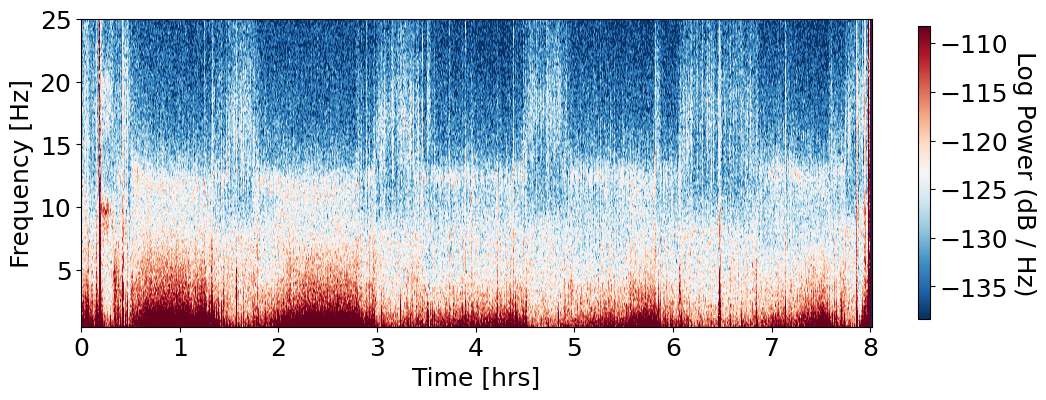

In [8]:
fig = yasa.plot_spectrogram(data_cz, sf=float(sf))


**Multi-taper spectrogram with the hypnogram***

Next, we load the sleep staging vector (a.k.a hypnogram), which is a simple text file in which each value represents 30 seconds of data. Sleep stages are encoded as integer (*0: Wake, 1: N1 sleep, 2: N2 sleep, 3: N3 sleep, 4: REM sleep*).

In the code below, we load our 30-sec hypnogram and upsample it to match the sampling frequency and length of data, using YASA's built-in [hypno_upsample_to_data](https://yasa-sleep.org/generated/yasa.hypno_upsample_to_data.html#yasa.hypno_upsample_to_data) function.

Please refer to [08_bandpower.ipynb](08_bandpower.ipynb) for more details on how to manipulate hypnogram in YASA.

In [10]:
hypno_30s_filepath = yasa.fetch_sample('full_6hrs_100Hz_hypno_30s.txt')
hypno_30s = np.loadtxt(hypno_30s_filepath)
hypno = yasa.hypno_upsample_to_data(hypno=hypno_30s, sf_hypno=(1/30), data=data, sf_data=sf)
print(hypno.shape, 'Unique values =', np.unique(hypno))

09-Mar-26 12:05:37 | WARNING | Hypnogram is SHORTER than data by 7285.67 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


(14442837,) Unique values = [-2.  0.  1.  2.  3.  4.]


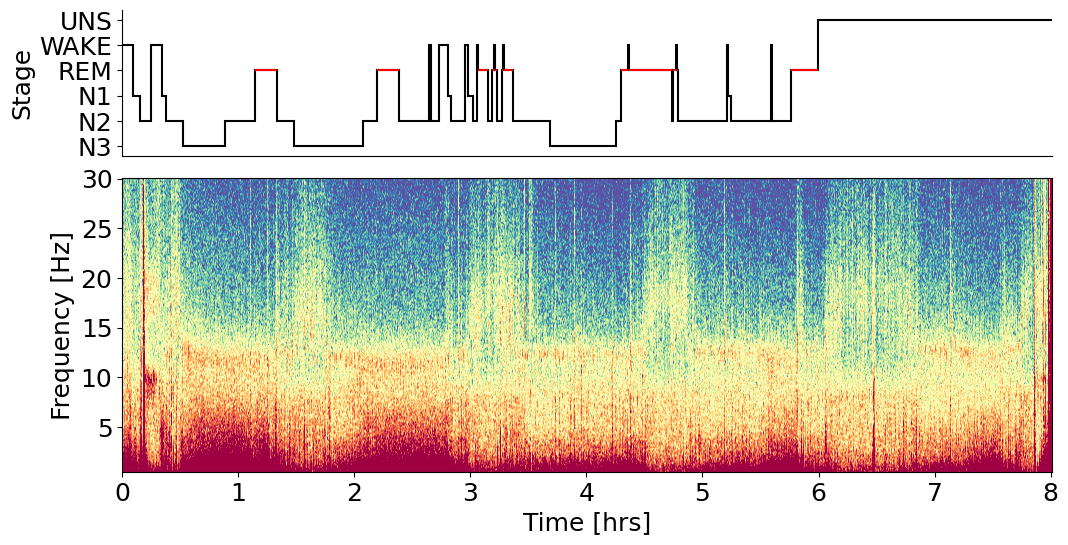

In [11]:
fig = yasa.plot_spectrogram(data_cz, sf, hypno=hypno, fmax=30, cmap='Spectral_r', trimperc=5)